# Figure Generation Notebook (Ecology 2026)

This notebook reproduces the manuscript figures for **Defense–Competition Trade-offs Shape Prey Eco-Evolutionary Dynamics Across Environmental Gradients** (Guariento et al., under review in *Ecology*).

## Reproducibility notes

Some figures in this notebook may differ slightly in appearance from those shown in the manuscript. A subset of panels was exported and then refined in vector-graphics software (for example, label positioning and minor formatting details), which was more practical than reproducing every visual adjustment directly in code. These edits are cosmetic only: the underlying model outputs, curve shapes, and qualitative conclusions are identical.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import integrate

plt.style.use('seaborn-v0_8-ticks')

PARAMS_TABLE_S1 = {
    'g': 5,
    'f_max_predation': 4,
    'e_N': 0.1,
    'e_P': 0.1,
    'd_N': 0.3,
    'd_P': 0.2,
    'lambda': 1,
    'K': 'variable',
    'alpha': 'variable',
}

PARAMS_ISO = {
    'g': 5,
    'f': 4,
    'e_p': 0.1,
    'c': 0.1,
    'd': 0.3,
    'dp': 0.2,
}

def color_fader(c1, c2, mix=0.0):
    c1 = np.array(mpl.colors.to_rgb(c1))
    c2 = np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1 - mix) * c1 + mix * c2)

print('Loaded common imports and parameter dictionaries.')

Loaded common imports and parameter dictionaries.


## Figure 2-style trade-off curves (direct predation risk)

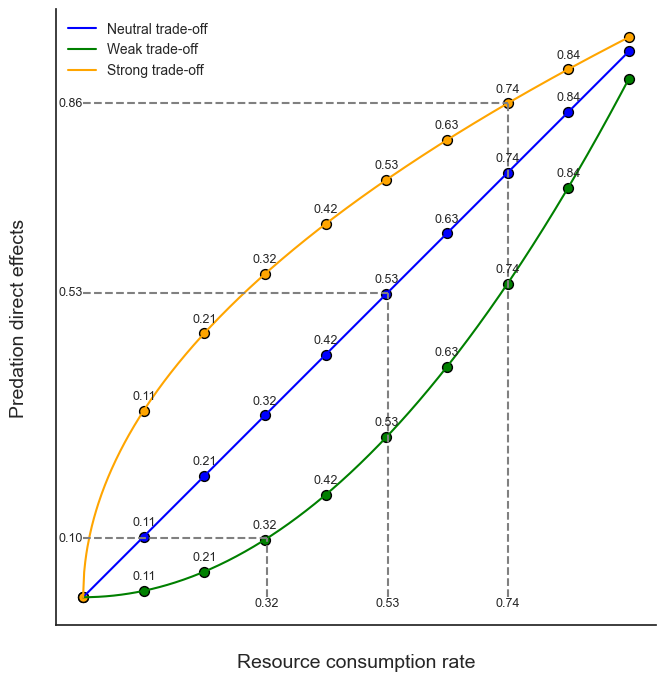

In [6]:
def plot_direct_risk_tradeoff(curves=(1, 2, 0.5), save_path='direct_risk.svg'):
    labels = ['Neutral trade-off', 'Weak trade-off', 'Strong trade-off']
    colors = ['blue', 'green', 'orange']
    x_points = np.linspace(0, 0.95, 10)

    fig, ax = plt.subplots(figsize=(8, 8))

    for a, label, color in zip(curves, labels, colors):
        x = np.linspace(0, 0.95, 500)
        y = x ** a
        ax.plot(x, y, label=label, color=color)

        y_points = x_points ** a
        ax.scatter(x_points, y_points, color=color, marker='o', s=50, edgecolor='black')

        for (xp, yp) in zip(x_points[1:-1], y_points[1:-1]):
            ax.text(xp, yp + 0.02, f'{xp:.2f}', fontsize=9, ha='center')

    highlight_points = [(0.32, 'green'), (0.74, 'orange'), (0.53, 'blue')]
    for highlight_x, color in highlight_points:
        a = curves[colors.index(color)]
        highlight_y = highlight_x ** a
        ax.plot([0, highlight_x], [highlight_y, highlight_y], color='gray', linestyle='--')
        ax.plot([highlight_x, highlight_x], [0, highlight_y], color='gray', linestyle='--')
        ax.text(highlight_x, 0, f'{highlight_x:.2f}', fontsize=9, ha='center', va='top')
        ax.text(0, highlight_y, f'{highlight_y:.2f}', fontsize=9, ha='right', va='center')

    ax.set_xlabel('Resource consumption rate', labelpad=20, fontsize=14)
    ax.set_ylabel('Predation direct effects', labelpad=20, fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()
    ax.set_aspect('equal', adjustable='box')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.savefig(save_path, dpi=150, bbox_inches='tight', format='svg')
    plt.show()

plot_direct_risk_tradeoff()

## Reversed defense-axis visualization

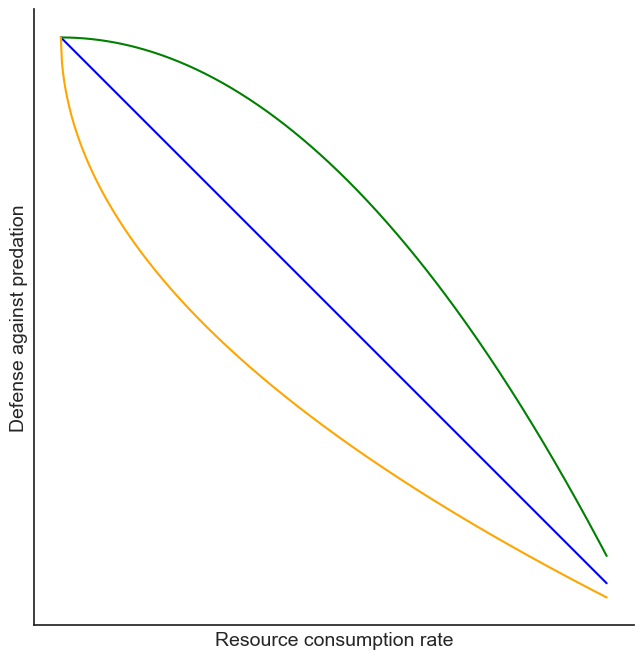

In [7]:
def plot_reversed_tradeoff(curves=(1, 2, 0.5), save_path='reversed_plot.svg'):
    colors = ['blue', 'green', 'orange']
    x = np.linspace(0, 0.95, 500)

    fig, ax = plt.subplots(figsize=(8, 8))
    for a, color in zip(curves, colors):
        ax.plot(x, -(x ** a), color=color)

    ax.set_xlabel('Resource consumption rate', fontsize=14)
    ax.set_ylabel('Defense against predation', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_aspect('equal', adjustable='box')

    fig.savefig(save_path, dpi=150, bbox_inches='tight', format='svg')
    plt.show()

plot_reversed_tradeoff()

## Figure 1 (one prey vs two prey with trade-off)

This figure is a schematic representation of how to interpret our graphical analysis. It can be generated using the code below, adapted from the Panel C ($\alpha = 2$) ZNGI workflow. Panel A shows the single-prey invasion framework (ZNGI, supply point, impact vector); Panel B overlays two prey ZNGIs whose trade-off produces a coexistence intersection and persistence regions.

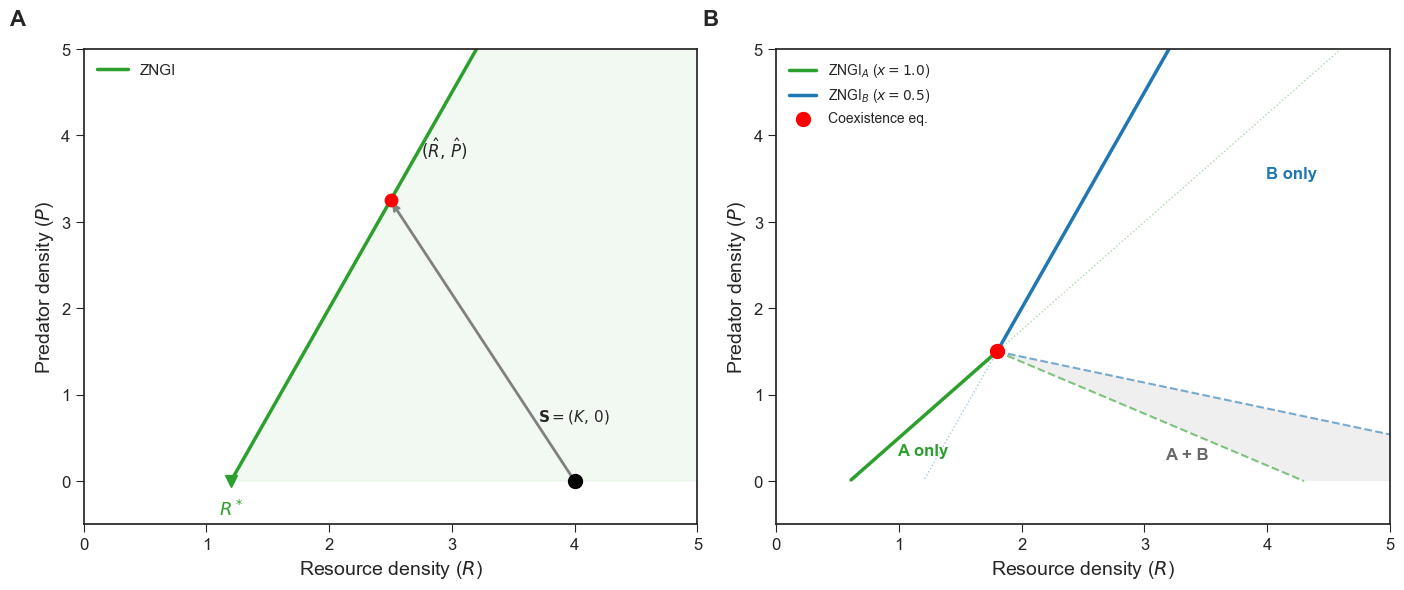

In [13]:
def plot_figure1(alpha=2, save_path='figure1.svg'):
    """Reproduce Figure 1: graphical framework for prey invasion analysis.

    Panel A — Single prey: ZNGI, supply point, and impact vector to equilibrium.
    Panel B — Two prey with trade-off: overlaid ZNGIs, coexistence intersection,
              impact vectors, and persistence-region annotations.
    Adapted from the ZNGI construction in the alpha = 2 panel.
    """
    g_val  = PARAMS_ISO['g']
    f_val  = PARAMS_ISO['f']
    e_p    = PARAMS_ISO['e_p']
    c_val  = PARAMS_ISO['c']
    d_val  = PARAMS_ISO['d']
    dp_val = PARAMS_ISO['dp']

    def zngi_curve(R, x):
        return (c_val * g_val * R * x - d_val) / (e_p * f_val * x ** alpha)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    R = np.linspace(0.01, 6, 500)

    # ── Panel A: single prey ─────────────────────────────────────
    x0 = 0.5
    P0 = zngi_curve(R, x0)
    pos = P0 >= 0

    ax1.plot(R[pos], P0[pos], color='#2ca02c', lw=2.5, label='ZNGI')
    ax1.fill_between(R[pos], 0, P0[pos], color='#2ca02c', alpha=0.06)

    # R* marker on x-axis
    R_star0 = d_val / (c_val * g_val * x0)
    ax1.plot(R_star0, 0, 'v', color='#2ca02c', ms=8, zorder=5)
    ax1.annotate(r'$R^*$', (R_star0, 0), xytext=(R_star0, -0.4),
                 fontsize=13, ha='center', color='#2ca02c')

    # Supply point
    K_show = 4.0
    ax1.scatter(K_show, 0, c='k', s=100, zorder=5)
    ax1.annotate(r'$\mathbf{S}=(K,\,0)$', (K_show, 0),
                 xytext=(K_show - 0.3, 0.7), fontsize=11)

    # Equilibrium point on ZNGI (chosen for visual clarity)
    R_eq = 2.5
    P_eq = zngi_curve(R_eq, x0)
    ax1.scatter(R_eq, P_eq, c='red', s=80, zorder=5)
    ax1.annotate(r'$(\hat{R},\,\hat{P})$', (R_eq, P_eq),
                 xytext=(R_eq + 0.25, P_eq + 0.5), fontsize=12)

    # Impact arrow: supply point → equilibrium
    ax1.annotate('', xy=(R_eq, P_eq), xytext=(K_show, 0),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=2))

    ax1.set_xlim(0, 5)
    ax1.set_ylim(-0.5, 5)
    ax1.set_xlabel('Resource density ($R$)', fontsize=14)
    ax1.set_ylabel('Predator density ($P$)', fontsize=14)
    ax1.tick_params(labelsize=12)
    ax1.legend(fontsize=11, loc='upper left')
    ax1.text(-0.12, 1.05, 'A', transform=ax1.transAxes,
             fontsize=16, fontweight='bold')

    # ── Panel B: two prey with trade-off ─────────────────────────
    x_A, x_B = 1.0, 0.5
    cA, cB = '#2ca02c', '#1f77b4'       # green / blue (as described in manuscript fig 1B)

    PA = zngi_curve(R, x_A)
    PB = zngi_curve(R, x_B)

    # Full curves (faint background)
    ax2.plot(R[PA >= 0], PA[PA >= 0], cA, lw=1, ls=':', alpha=0.4)
    ax2.plot(R[PB >= 0], PB[PB >= 0], cB, lw=1, ls=':', alpha=0.4)

    # ZNGI intersection
    r_s = d_val * (-x_A**alpha + x_B**alpha) / (
        c_val * g_val * (x_A * x_B**alpha - x_B * x_A**alpha))
    p_s = zngi_curve(r_s, x_A)

    # Outermost segments (solid)
    mA = (R <= r_s) & (PA >= 0)
    mB = R >= r_s
    ax2.plot(R[mA], PA[mA], cA, lw=2.5, label=f'ZNGI$_A$ ($x={x_A}$)')
    ax2.plot(R[mB], PB[mB], cB, lw=2.5, label=f'ZNGI$_B$ ($x={x_B}$)')

    # Intersection marker
    ax2.scatter(r_s, p_s, c='red', s=100, zorder=5, label='Coexistence eq.')

    # Impact-vector slopes from intersection
    sl_A = (p_s * (-(e_p * f_val) * x_A**alpha / dp_val)) / \
           (r_s * (g_val * x_A / r_s))
    sl_B = (p_s * (-(e_p * f_val) * x_B**alpha / dp_val)) / \
           (r_s * (g_val * x_B / r_s))

    def iv_end(slope, xmax=5.0):
        """Clip impact line to plot rectangle."""
        R_at_P0 = r_s - p_s / slope
        if R_at_P0 <= xmax:
            return (R_at_P0, 0.0)
        return (xmax, p_s + slope * (xmax - r_s))

    eA = iv_end(sl_A)
    eB = iv_end(sl_B)

    ax2.plot([r_s, eA[0]], [p_s, eA[1]], cA, lw=1.5, ls='--', alpha=0.6)
    ax2.plot([r_s, eB[0]], [p_s, eB[1]], cB, lw=1.5, ls='--', alpha=0.6)

    # Coexistence cone shading
    cone = [(r_s, p_s), eA]
    if eA[1] == 0 and eB[1] > 0:
        cone += [(eB[0], 0.0), eB]
    elif eA[1] == 0 and eB[1] == 0:
        cone += [eB]
    else:
        cone += [eB]
    ax2.add_patch(plt.Polygon(cone, closed=True,
                              fc='gray', alpha=0.12, ec='none', zorder=1))

    # Region labels
    ax2.text(1.2, 0.3, 'A only', fontsize=12, color=cA,
             fontweight='bold', ha='center')
    ax2.text(4.2, 3.5, 'B only', fontsize=12, color=cB,
             fontweight='bold', ha='center')
    ax2.text((r_s + eA[0]) / 2 + 0.3, 0.25, 'A + B', fontsize=12,
             color='dimgray', fontweight='bold', ha='center')

    ax2.set_xlim(0, 5)
    ax2.set_ylim(-0.5, 5)
    ax2.set_xlabel('Resource density ($R$)', fontsize=14)
    ax2.set_ylabel('Predator density ($P$)', fontsize=14)
    ax2.tick_params(labelsize=12)
    ax2.legend(fontsize=10, loc='upper left')
    ax2.text(-0.12, 1.05, 'B', transform=ax2.transAxes,
             fontsize=16, fontweight='bold')

    fig.tight_layout()
    fig.savefig(save_path, format='svg', dpi=200, bbox_inches='tight')
    plt.show()

plot_figure1()

## ZNGIs across trade-off shapes

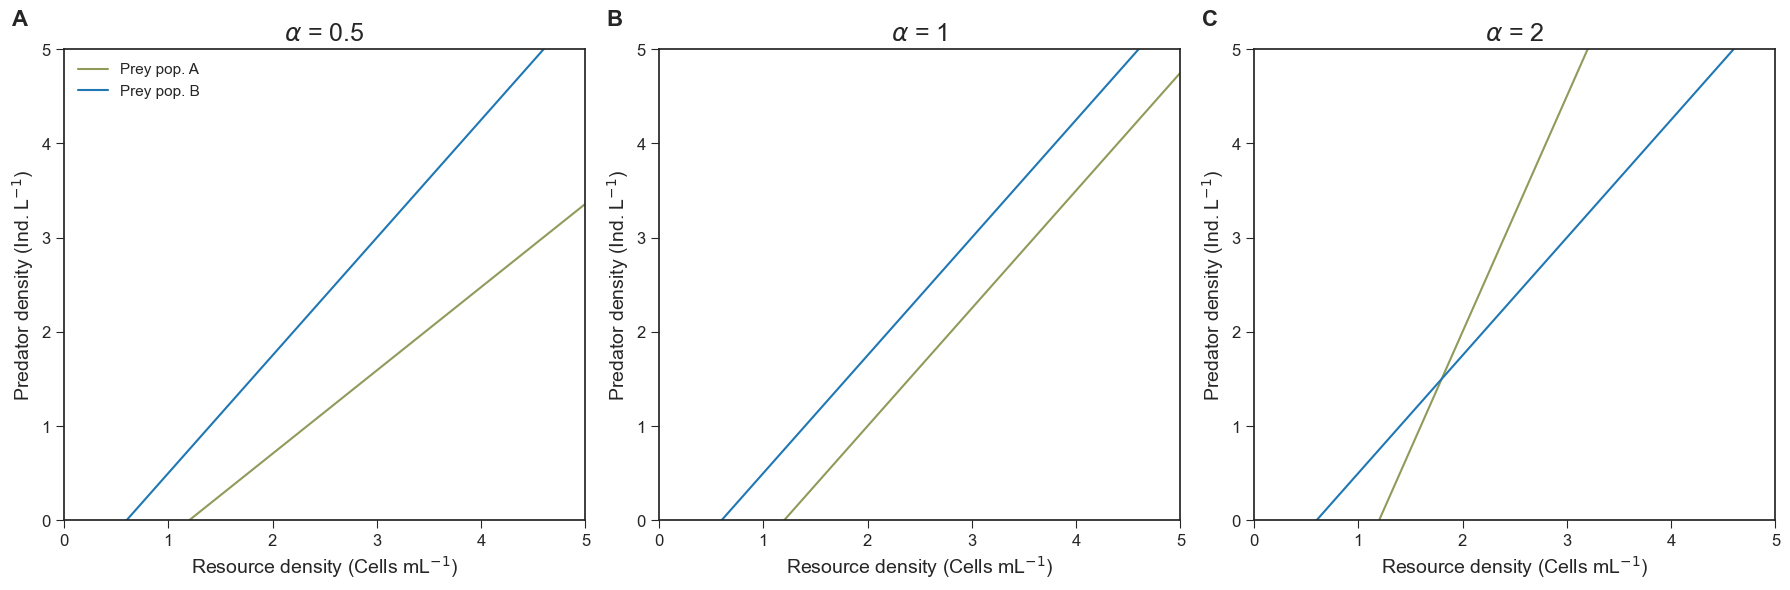

In [7]:
def plot_zngi_by_alpha(a_values=(0.5, 1, 2), zngi_number=2, save_path='zngi_by_alpha.svg'):
    c1, c2 = '#FFBF00', '#1f77b4'
    g, f, e_p, c, d = (
        PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'], PARAMS_ISO['c'], PARAMS_ISO['d']
    )

    R = np.linspace(0.01, 10, 100)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (ax, alpha) in enumerate(zip(axes, a_values)):
        for x in range(1, zngi_number + 1):
            frac = x / zngi_number
            zngi = (c * g * R * frac - d) / (e_p * f * frac ** alpha)
            ax.plot(R, zngi, color=color_fader(c1, c2, frac), linewidth=1.5, label=f'$x$={frac:.2f}')

        ax.set_ylim([0, 5])
        ax.set_xlim([0, 5])
        ax.set_title(r'$\alpha$ = ' + f'{alpha}', fontsize=18)
        ax.set_xlabel('Resource density (Cells mL$^{-1}$)', fontsize=14)
        ax.set_ylabel('Predator density (Ind. L$^{-1}$)', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.text(-0.1, 1.05, chr(65 + idx), transform=ax.transAxes, fontsize=16, fontweight='bold')

        if idx == 0:
            ax.legend(labels=['Prey pop. A', 'Prey pop. B'], fontsize=11)

    fig.tight_layout()
    fig.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()

plot_zngi_by_alpha()

## Outermost ZNGI, intersections, and impact vectors

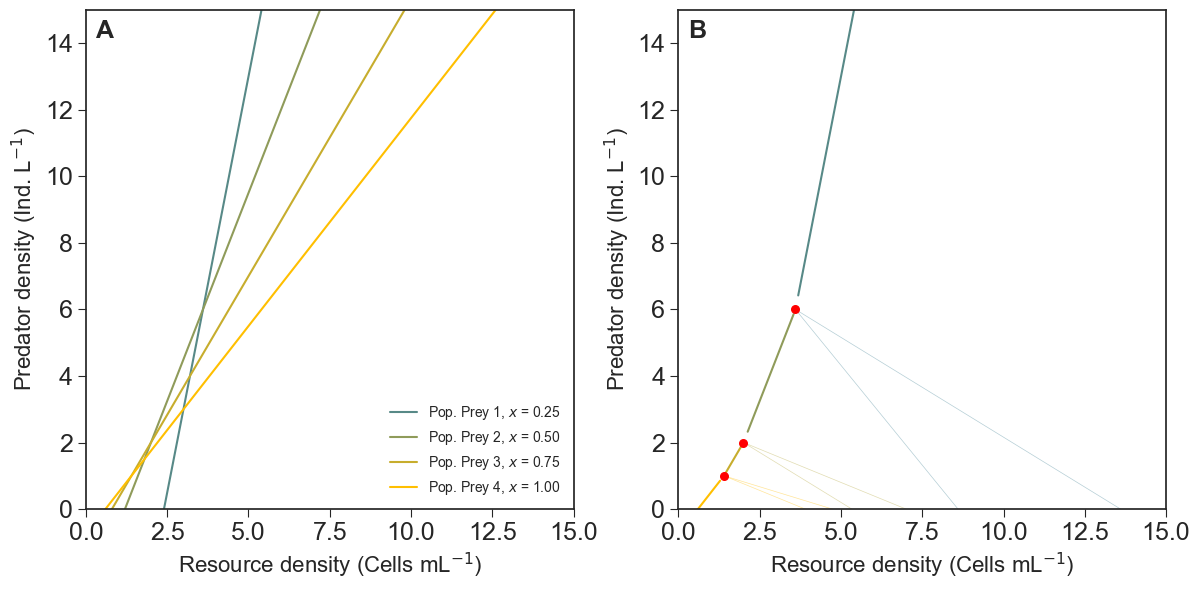

In [5]:
def plot_outermost_zngi_and_impacts(zngi_number=4, alpha=2, save_path='outermost_zngi_impacts.svg'):
    c1, c2 = '#1f77b4', '#FFBF00'
    g, f, e_p, c, d, dp = (
        PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'], PARAMS_ISO['c'], PARAMS_ISO['d'], PARAMS_ISO['dp']
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Panel A: all ZNGIs
    R1 = np.linspace(0, 14, 100)
    for x in range(1, zngi_number + 1):
        frac = x / zngi_number
        zngi = (c * g * R1 * frac - d) / ((e_p * f) * (frac ** alpha))
        label = f'Pop. Prey {x}, $x$ = {frac:.2f}'
        ax1.plot(R1, zngi, color=color_fader(c1, c2, frac), linewidth=1.5, alpha=1, label=label)

    ax1.set_ylim([0, 15])
    ax1.set_xlim([0, 15])
    ax1.set_xlabel('Resource density (Cells mL$^{-1}$)', fontsize=16)
    ax1.set_ylabel('Predator density (Ind. L$^{-1}$)', fontsize=16)
    ax1.tick_params(axis='both', labelsize=18)
    ax1.text(0.02, 0.98, 'A', transform=ax1.transAxes, fontsize=18, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    ax1.legend()

    # Panel B: outermost ZNGI + intersections + impact vectors
    R2 = np.linspace(0.01, 14, 100)
    zngis = []
    for x in range(1, zngi_number + 1):
        frac = x / zngi_number
        zngi = (c * g * R2 * frac - d) / ((e_p * f) * (frac ** alpha))
        zngis.append(zngi)

    outermost = np.maximum.reduce(zngis)
    for i, zngi in enumerate(zngis):
        mask = zngi == outermost
        ax2.plot(R2[mask], zngi[mask], color=color_fader(c1, c2, (i + 1) / zngi_number), linewidth=1.5, alpha=1)

    ax2.set_ylim([0, 15])
    ax2.set_xlim([0, 15])
    ax2.set_xlabel('Resource density (Cells mL$^{-1}$)', fontsize=16)
    ax2.set_ylabel('Predator density (Ind. L$^{-1}$)', fontsize=16)
    ax2.tick_params(axis='both', labelsize=18)
    ax2.text(0.02, 0.98, 'B', transform=ax2.transAxes, fontsize=18, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    star_values = pd.DataFrame(columns=['index', 'RStar', 'PStar', 'x_value_1', 'x_value_2'])
    index = 0
    for x in range(1, zngi_number + 1):
        x_value_1 = x / zngi_number
        for w in range(x + 1, zngi_number + 1):
            x_value_2 = w / zngi_number
            r_star = d * (-x_value_1 ** alpha + x_value_2 ** alpha) / (
                c * g * (x_value_1 * x_value_2 ** alpha - x_value_2 * x_value_1 ** alpha)
            )
            p_star = (c * g * r_star * x_value_1 - d) / ((e_p * f) * x_value_1 ** alpha)

            index += 1
            star_values.loc[index] = [index, r_star, p_star, x_value_1, x_value_2]

    outermost_intersections = star_values.loc[
        (star_values['PStar'] >= np.min(outermost)) &
        (star_values['PStar'] <= np.max(outermost))
    ]
    selected_intersections = outermost_intersections.iloc[[0, 3, 5]] if len(outermost_intersections) >= 6 else outermost_intersections

    for _, row in selected_intersections.iterrows():
        ax2.scatter(row['RStar'], row['PStar'], color='red', s=30, zorder=5)

    for _, row in selected_intersections.iterrows():
        impact_eq_nx_r_1 = g * row['x_value_1'] / row['RStar']
        impact_eq_nx_p_1 = -(e_p * f) * row['x_value_1'] ** alpha / dp
        impact_eq_nx_r_2 = g * row['x_value_2'] / row['RStar']
        impact_eq_nx_p_2 = -(e_p * f) * row['x_value_2'] ** alpha / dp

        x112 = [row['RStar'], row['RStar'] * (1 + impact_eq_nx_r_1 * 10)]
        y112 = [row['PStar'], row['PStar'] * (1 + impact_eq_nx_p_1 * 10)]
        x212 = [row['RStar'], row['RStar'] * (1 + impact_eq_nx_r_2 * 10)]
        y212 = [row['PStar'], row['PStar'] * (1 + impact_eq_nx_p_2 * 10)]

        mix = row['index'] / index if index > 0 else 0.5
        ax2.plot(x112, y112, color=color_fader(c1, c2, mix), linewidth=0.5, alpha=0.4)
        ax2.plot(x212, y212, color=color_fader(c1, c2, mix), linewidth=0.5, alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, format='svg', dpi=150)
    plt.show()

plot_outermost_zngi_and_impacts()

## Eco-evolutionary dynamics along the resource supply gradient

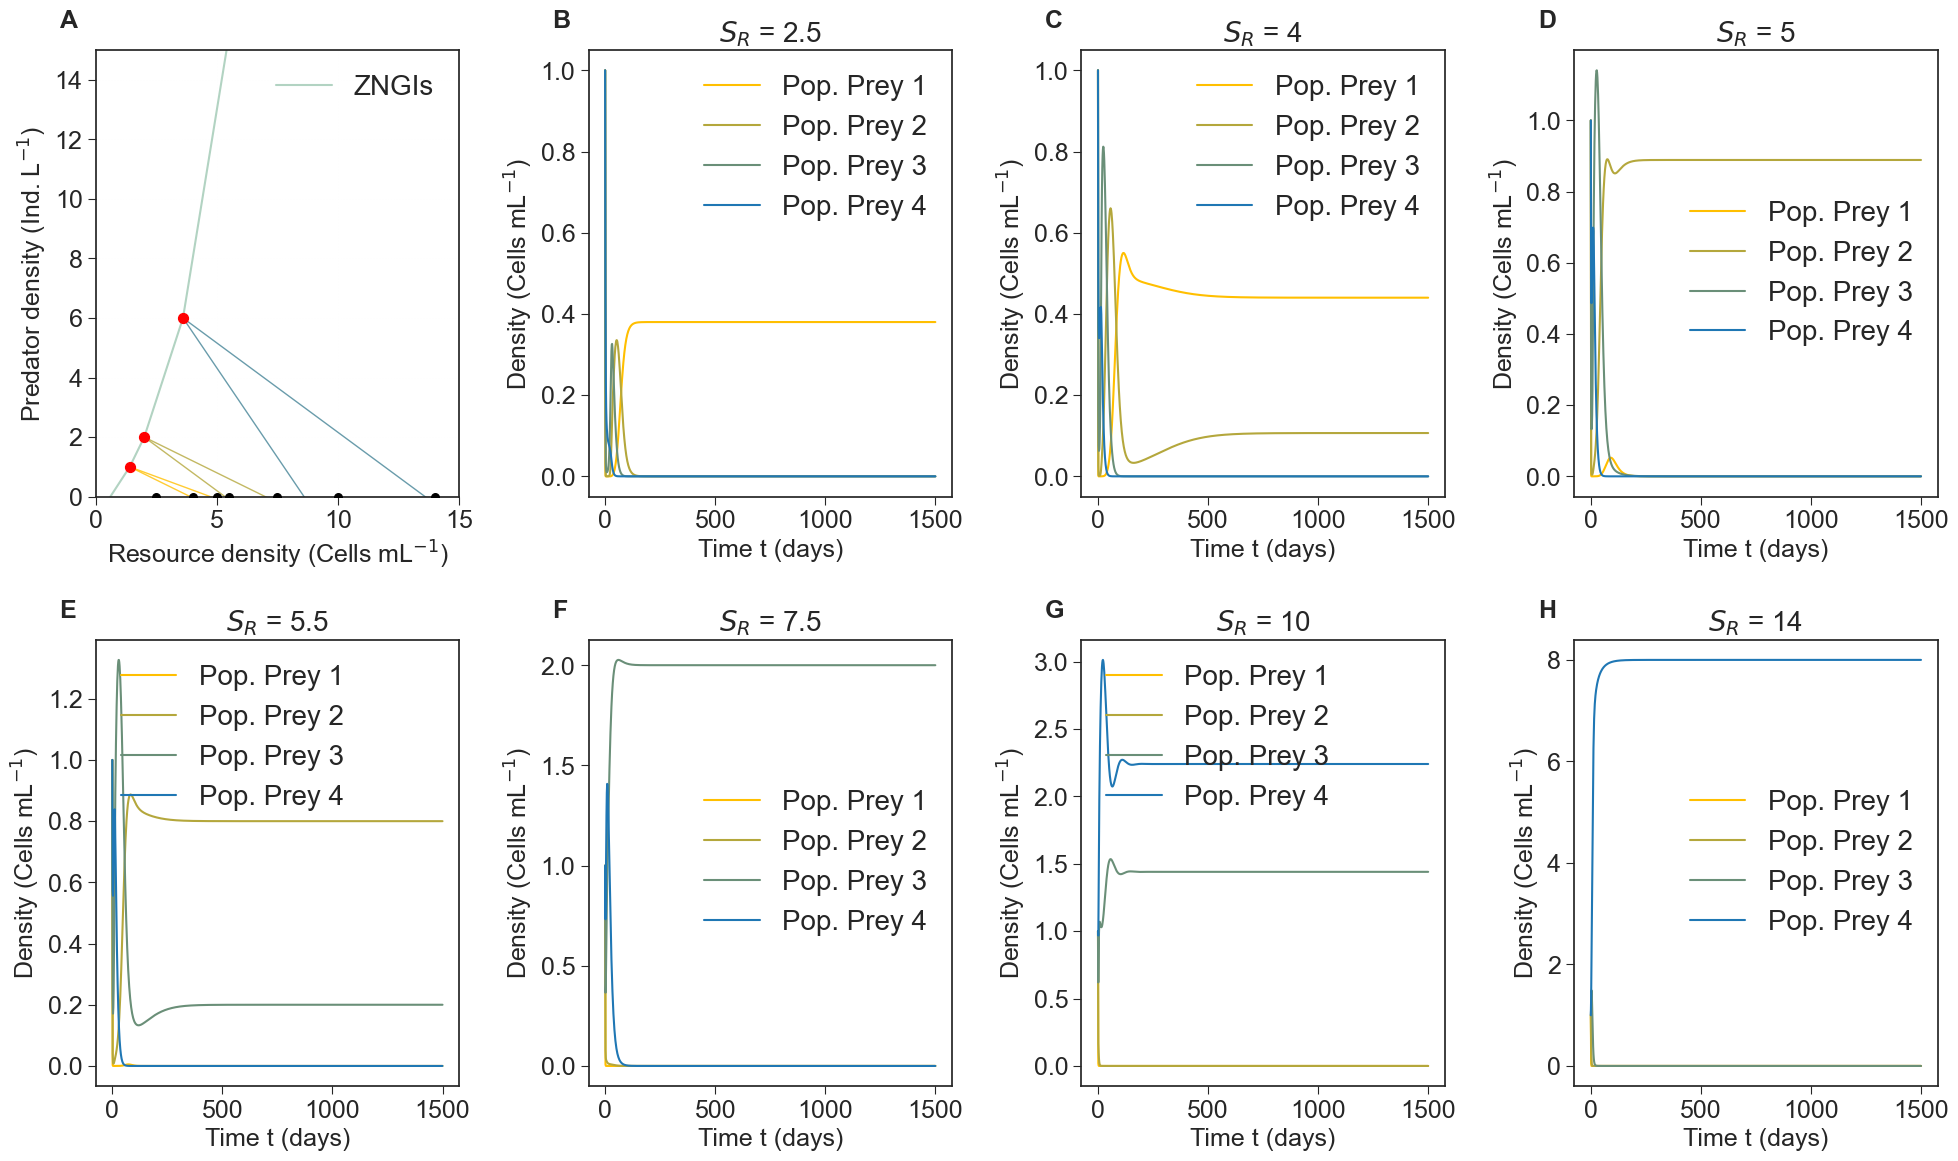

In [33]:
def model(X, t, alpha, x1, x2, x3, x4, c, g, f, e_p, d, dp, K, r, IZ):
    n1, n2, n3, n4, R, P = X
    n1dot = n1 * (g * c * x1 * R - (f) * (x1 ** alpha) * P - d)
    n2dot = n2 * (g * c * x2 * R - (f) * (x2 ** alpha) * P - d)
    n3dot = n3 * (g * c * x3 * R - (f) * (x3 ** alpha) * P - d)
    n4dot = n4 * (g * c * x4 * R - (f) * (x4 ** alpha) * P - d)
    Rdot = r * (K - R) * R - g * R * (x1 * n1 + x2 * n2 + x3 * n3 + x4 * n4)
    Pdot = P * ((e_p * f) * ((x1 ** alpha) * n1 + (x2 ** alpha) * n2 + (x3 ** alpha) * n3 + (x4 ** alpha) * n4) - dp)
    return np.array([n1dot, n2dot, n3dot, n4dot, Rdot, Pdot])

def run_simulation(K, Nt=1000, tmax=1500):
    alpha = 2
    x1, x2, x3, x4 = 1.0, 0.75, 0.5, 0.25
    c, g, f, e_p = 0.1, 5, 4, 0.1
    d, dp = 0.3, 0.2
    r, IZ = 1, 0.0

    X0 = [1.0, 1.0, 1.0, 1.0, K, 1.0]
    t = np.linspace(0.0, tmax, Nt)
    res = integrate.odeint(model, X0, t, args=(alpha, x1, x2, x3, x4, c, g, f, e_p, d, dp, K, r, IZ))
    return t, res

def plot_timeseries_by_K(K_values=(2.5, 4, 5, 5.5, 7.5, 10, 14), save_path='timeseries_by_K.svg'):
    c_blue, c_amber = '#1f77b4', '#FFBF00'
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    axes = axes.flatten()

    # Panel A: Outermost isocline + supply points + intersections + impact vectors
    ax0 = axes[0]
    g_iso, f_iso, e_p_iso, c_iso, d_iso, dp_iso = 5, 4, 0.1, 0.1, 0.3, 0.2
    zngi_number = 4
    alpha_iso = 2
    R_iso = np.linspace(0.01, 10, 100)

    zngis = []
    for x in range(1, zngi_number + 1):
        frac = x / zngi_number
        zngi_x = (c_iso * g_iso * R_iso * frac - d_iso) / ((e_p_iso * f_iso) * frac ** alpha_iso)
        zngis.append(zngi_x)

    outermost_zngi = np.maximum.reduce(zngis)
    ax0.plot(R_iso, outermost_zngi, color='#B2D3C2', linewidth=1.5, alpha=1, label='ZNGIs')

    ax0.set_ylim([0, 15])
    ax0.set_xlim([0, 15])
    ax0.set_xlabel('Resource density (Cells mL$^{-1}$)')
    ax0.set_ylabel('Predator density (Ind. L$^{-1}$)')
    ax0.grid(True, linestyle=':', alpha=0.01)

    for K in K_values:
        ax0.scatter(K, 0, color='black', s=30, zorder=5)

    star_values = []
    index = 0
    for x in range(1, zngi_number + 1):
        x_value_1 = x / zngi_number
        for w in range(x + 1, zngi_number + 1):
            x_value_2 = w / zngi_number
            r_star = d_iso * (-x_value_1 ** alpha_iso + x_value_2 ** alpha_iso) / (
                c_iso * g_iso * (x_value_1 * x_value_2 ** alpha_iso - x_value_2 * x_value_1 ** alpha_iso)
            )
            p_star = (c_iso * g_iso * r_star * x_value_1 - d_iso) / ((e_p_iso * f_iso) * x_value_1 ** alpha_iso)

            index += 1
            star_values.append((index, r_star, p_star, x_value_1, x_value_2))

    star_df = pd.DataFrame(star_values, columns=['index', 'RStar', 'PStar', 'x_value_1', 'x_value_2'])
    outermost_intersections = star_df[
        (star_df['PStar'] >= np.min(outermost_zngi)) &
        (star_df['PStar'] <= np.max(outermost_zngi))
    ]

    selected_intersections = outermost_intersections.iloc[[0, 3, 5]] if len(outermost_intersections) >= 6 else outermost_intersections

    for _, row in selected_intersections.iterrows():
        ax0.scatter(row['RStar'], row['PStar'], color='red', s=50, zorder=5)

    for _, row in selected_intersections.iterrows():
        impact_eq_nx_r_1 = g_iso * row['x_value_1'] / row['RStar']
        impact_eq_nx_p_1 = -(e_p_iso * f_iso) * row['x_value_1'] ** alpha_iso / dp_iso
        impact_eq_nx_r_2 = g_iso * row['x_value_2'] / row['RStar']
        impact_eq_nx_p_2 = -(e_p_iso * f_iso) * row['x_value_2'] ** alpha_iso / dp_iso

        x112 = [row['RStar'], row['RStar'] * (1 + impact_eq_nx_r_1 * 10)]
        y112 = [row['PStar'], row['PStar'] * (1 + impact_eq_nx_p_1 * 10)]
        x212 = [row['RStar'], row['RStar'] * (1 + impact_eq_nx_r_2 * 10)]
        y212 = [row['PStar'], row['PStar'] * (1 + impact_eq_nx_p_2 * 10)]

        mix = row['index'] / index if index > 0 else 0.5
        ax0.plot(x112, y112, color=color_fader(c_blue, c_amber, mix), linewidth=1, alpha=0.8)
        ax0.plot(x212, y212, color=color_fader(c_blue, c_amber, mix), linewidth=1, alpha=0.8)

    ax0.legend()

    panel_labels = list('ABCDEFGH')
    ax0.text(-0.1, 1.05, panel_labels[0], transform=ax0.transAxes, fontsize=18, fontweight='bold')

    # Panels B-H: time series across K
    for i, K in enumerate(K_values):
        ax = axes[i + 1]
        t, res = run_simulation(K)
        n1, n2, n3, n4, _, _ = res.T

        for j, data in enumerate([n1, n2, n3, n4]):
            color = color_fader(c_amber, c_blue, j / 3)
            ax.plot(t, data, color=color, label=f'Pop. Prey {j+1}')

        ax.set_title(f'$S_R$ = {K}')
        ax.set_xlabel('Time t (days)')
        ax.set_ylabel('Density (Cells mL$^{-1}$)')
        ax.legend()
        ax.text(-0.1, 1.05, panel_labels[i + 1], transform=ax.transAxes, fontsize=18, fontweight='bold')

    fig.tight_layout()
    fig.savefig(save_path, format='svg', dpi=150)
    plt.show()

plot_timeseries_by_K()

## Pairwise invasibility plots (PIP)

Alpha=2: Point at Z=0 with negative invasion fitness above/below and positive invasion fitness left/right found at: x = 0.5994736842105264, y = 0.5994736842105264


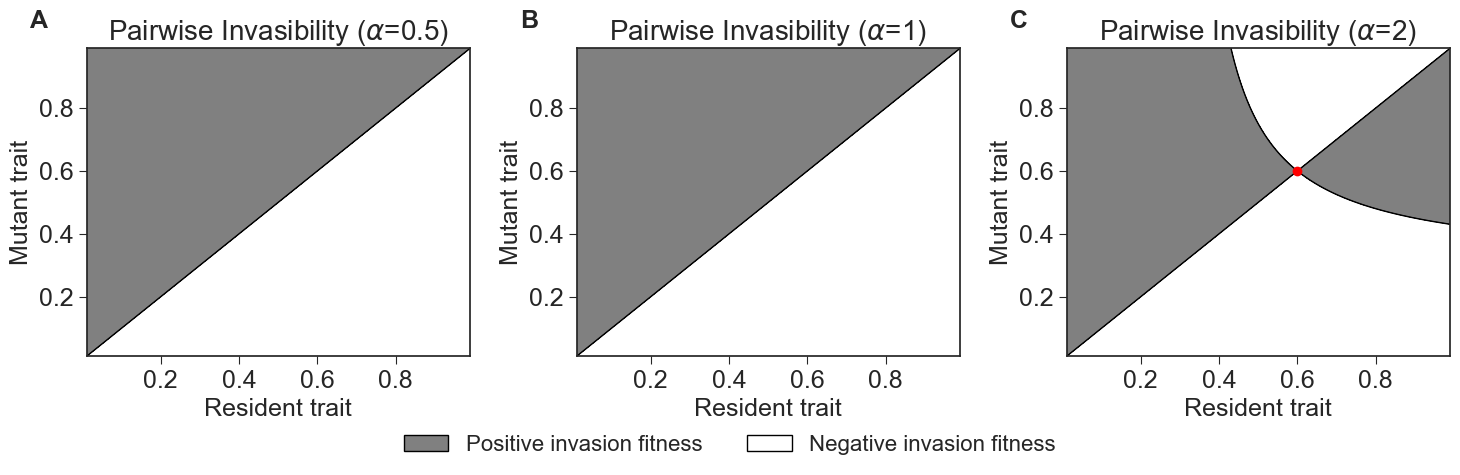

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Constants
g = 5
f = 4
e_p = 0.1
c = 0.1
d = 0.3
R = 2
P = 0

# Define the fitness function
def fitness(x, y, alpha):
    return g * c * y * R - (e_p * f) * (y ** alpha) * (R * c * g * x - d) / ((e_p * f) * (x ** alpha)) - d

# Define the invasion fitness function
def invasion_fitness(x, y, alpha):
    return fitness(x, y, alpha) - fitness(x, x, alpha)

# Generate the plot data
x = np.linspace(0.01, 0.99, 400)
y = np.linspace(0.01, 0.99, 400)
X, Y = np.meshgrid(x, y)

# Values of alpha to plot
alpha_values = [0.5, 1, 2]

# Adjust global font sizes
plt.rcParams.update({'font.size': 20})  # Increase global font size
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

# Create the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (ax, alpha) in enumerate(zip(axes, alpha_values)):
    Z = invasion_fitness(X, Y, alpha)

    # Create a custom colormap: white for negative values, grey for positive values
    cmap = ListedColormap(['white', 'grey'])
    norm = BoundaryNorm([-1, 0, 1], cmap.N)  # Set boundaries for the colormap

    # Plot the positive and negative values separately
    contour_neg = ax.contourf(X, Y, Z, levels=np.linspace(Z.min(), 0, 100), cmap=ListedColormap(['white']))
    contour_pos = ax.contourf(X, Y, Z, levels=np.linspace(0, Z.max(), 100), cmap=ListedColormap(['grey']))

    # Add the zero contour line
    contour_zero = ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=1)

    # Add a black border around the white region (negative values)
    ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=0.5, linestyles='-')

    # Scan for points where Z=0, white above/below, grey left/right (approximation to find ESS)
    highlight_point = None
    for i in range(1, Z.shape[0]-1):
        for j in range(1, Z.shape[1]-1):
            if Z[i, j] == 0:  # Z = 0 at this point
                if Z[i-1, j] < 0 and Z[i+1, j] < 0:  # white above and below (negative values)
                    if Z[i, j-1] > 0 and Z[i, j+1] > 0:  # grey left and right (positive values)
                        highlight_point = (x[j], y[i])  # Save the point for highlighting
                        print(f"Alpha={alpha}: Point at Z=0 with negative invasion fitness above/below and positive invasion fitness left/right found at: x = {x[j]}, y = {y[i]}")
                        break  # Stop once we find the first point

    # Highlight the point in the plot if it was found
    if highlight_point:
        ax.plot(highlight_point[0], highlight_point[1], 'ro', markersize=6, label='Highlighted Point')

    # Add axis labels and title
    ax.set_xlabel('Resident trait', fontsize=18)
    ax.set_ylabel('Mutant trait', fontsize=18)
    ax.set_title(r'Pairwise Invasibility ($\alpha$={})'.format(alpha), fontsize=20)  # Fixed LaTeX string for alpha
    ax.text(-0.1, 1.05, chr(65 + idx), transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='bottom', ha='right')

# Add overall legend for grey and white regions
fig.legend([plt.Rectangle((0, 0), 1, 1, edgecolor='black', facecolor='grey'),
            plt.Rectangle((0, 0), 1, 1, edgecolor='black', facecolor='white')],
           ['Positive invasion fitness', 'Negative invasion fitness'],
           loc='lower center', ncol=2, fontsize=16, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to fit legend
plt.savefig('output_image.png', dpi=300)  # Export image as PNG with 150 dpi
plt.show()

## Supplementary Figure S3

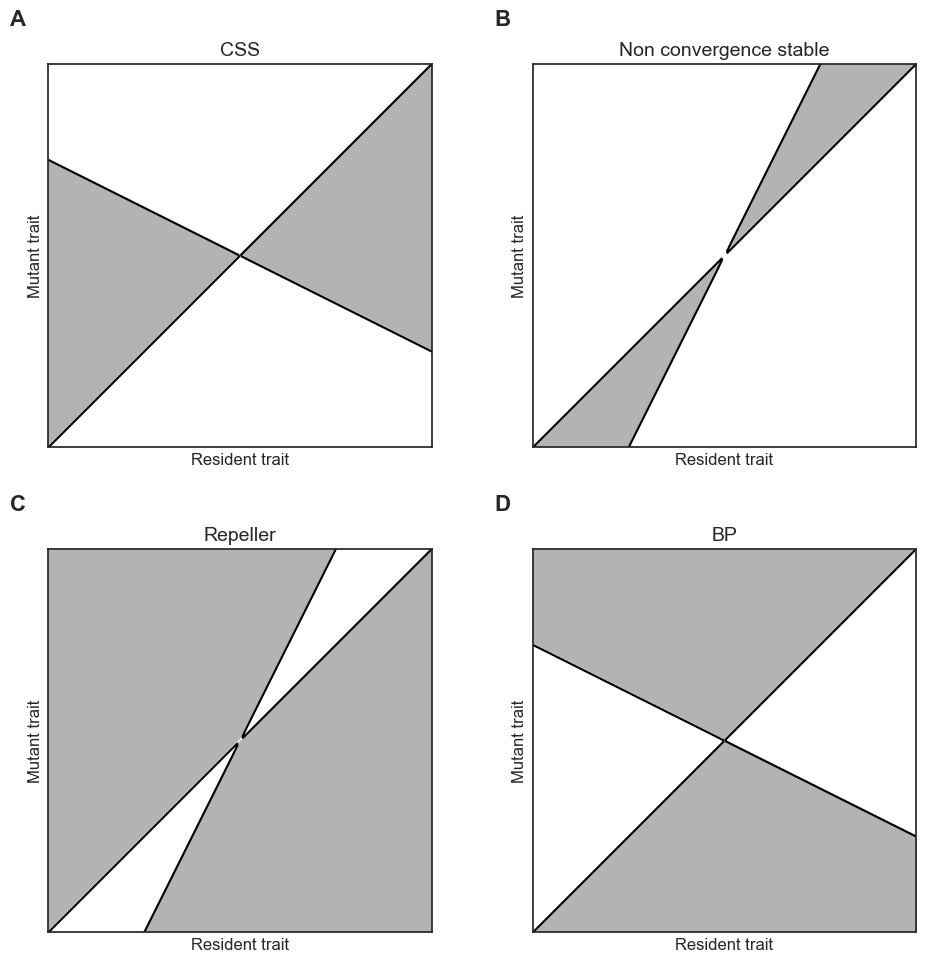

In [21]:
from matplotlib.gridspec import GridSpec

def create_pip_plot(index, a_vals, b_vals):
    x = np.linspace(0, 1, 200)
    y = np.linspace(0, 1, 200)
    X, Y = np.meshgrid(x, y)
    Z = b_vals[index] * (X - Y) * (a_vals[index] * (X - 0.5) - (Y - 0.5))

    ax = plt.gca()
    ax.contour(X, Y, Z, levels=[0], colors='black')
    ax.imshow(Z > 0, extent=[0, 1, 0, 1], origin='lower', cmap='binary', alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('Resident trait', fontsize=12)
    ax.set_ylabel('Mutant trait', fontsize=12)

def plot_pip_panel(save_path='pip_panel.png'):
    a_vals = [2, 1/2, -1/2, -2, 2, 1/2, -1/2, -2]
    b_vals = [1, 1, 1, 1, -1, -1, -1, -1]

    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(2, 2, figure=fig)

    pip_indices = [7, 5, 1, 3]
    pip_labels = ['CSS', 'Non convergence stable', 'Repeller', 'BP']
    panel_labels = ['A', 'B', 'C', 'D']

    for i, (index, label, panel_label) in enumerate(zip(pip_indices, pip_labels, panel_labels)):
        ax = fig.add_subplot(gs[i // 2, i % 2])
        create_pip_plot(index - 1, a_vals, b_vals)
        ax.set_title(label, fontsize=14)
        ax.text(-0.1, 1.1, panel_label, transform=ax.transAxes, fontsize=16, fontweight='bold')

    fig.tight_layout()
    fig.savefig(save_path, format='png', dpi=150, bbox_inches='tight')
    plt.show()

plot_pip_panel()

## Supplementary Figure S4

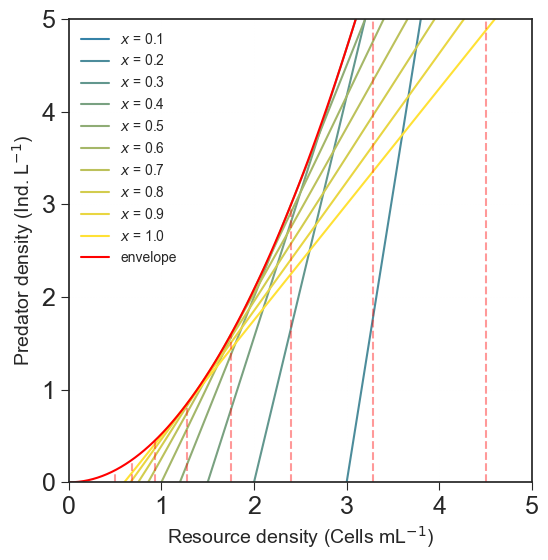

In [28]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

def colorFader(c1, c2, mix=0):
    c1 = np.array(mpl.colors.to_rgb(c1))
    c2 = np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1 - mix) * c1 + mix * c2)

# Parameters
c1 = '#1f77b4'  # blue
c2 = '#FFE135'  # columbia blue
g = 5
f = 4
e_p = 0.1
c = 0.1
d = 0.3
dp = 0.2
a = 2
zngi_number = 10

# Create figure
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(6, 6))

# Generate ZNGI curves
R = np.linspace(0.01, 5, 100)

# Plot ZNGIs
for x in range(1, zngi_number + 1):
    x_value = x / zngi_number

    def ZNGI_x(R):
        return ((c * g * R * x_value - d) / ((e_p * f) * x_value ** a))

    P_values = ZNGI_x(R)
    ax.plot(R, P_values, color=colorFader(c1, c2, x_value),
            linewidth=1.5, alpha=1, label=f'$x$ = {x_value}')

# Define and plot envelope
def envelope(R):
    return (R ** 2 * c ** 2 * g ** 2 / (4 * d * (e_p * f)))

R_envelope = np.linspace(0.01, 5, 100)
ax.plot(R_envelope, envelope(R_envelope), label='envelope', color='red')

# Calculate and plot impact vectors with varying magnitudes
# We'll space them logarithmically to better show the effect
R_impacts = np.logspace(np.log10(0.5), np.log10(4.5), 8)
for R_value in R_impacts:
    P_start = 0  # Starting from P=0

    # The envelope function determines the magnitude
    P_end = envelope(R_value)

    # Plot vector as dashed red line with varying length
    ax.plot([R_value, R_value], [P_start, P_end],
            color='red', linestyle='--', alpha=0.4)

# Set plot parameters
ax.set_ylim([0, 5])
ax.set_xlim([0, 5])
ax.set_xlabel("Resource density (Cells mL$^{-1}$)", fontsize=14)
ax.set_ylabel("Predator density (Ind. L$^{-1}$)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.01)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('output_image.png', format='png', dpi=300, bbox_inches='tight')
plt.show()
